# CSE437 Data Science — Phase 3  
## Data Transformation and Feature Engineering  
**Project:** *Evaluation of Vision–Language Baselines on a Defined VizWiz-VQA Subset: Answer Accuracy and Error Analysis for Low-Quality and Unanswerable Images*





In [ ]:
# 2. Imports, reproducibility, and Colab detection

from pathlib import Path
import json
import re
import math
import random
import warnings
import os
import tarfile
import zipfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageStat, ImageFilter, UnidentifiedImageError

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import joblib

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

IN_COLAB = False
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    pass

print("Environment ready.")
print("Running in Google Colab:", IN_COLAB)

Environment ready.
Running in Google Colab: True


In [ ]:


AUTO_UPLOAD_IF_MISSING = True
MOUNT_GOOGLE_DRIVE = False
IMAGE_FEATURE_LIMIT = None
SUBSET_SIZE = 1000

if IN_COLAB:
    PROJECT_ROOT = Path("/content")
else:
    PROJECT_ROOT = Path(".").resolve()

WORK_DATA_DIR = PROJECT_ROOT / "vizwiz_data"
FIGURE_DIR = PROJECT_ROOT / "figures"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

WORK_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if IN_COLAB and MOUNT_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

SEARCH_ROOTS = [
    WORK_DATA_DIR,
    PROJECT_ROOT / "data",
    PROJECT_ROOT,
]

if IN_COLAB and Path("/content/drive/MyDrive").exists():
    SEARCH_ROOTS.append(Path("/content/drive/MyDrive"))

print("Project root:", PROJECT_ROOT)
print("Working data directory:", WORK_DATA_DIR)
print("Search roots:")
for root in SEARCH_ROOTS:
    print(" -", root)

Project root: /content
Working data directory: /content/vizwiz_data
Search roots:
 - /content/vizwiz_data
 - /content/data
 - /content


In [ ]:


def extract_archive(path, destination):
    path = Path(path)
    destination = Path(destination)
    destination.mkdir(parents=True, exist_ok=True)

    lower = path.name.lower()
    try:
        if lower.endswith(".zip"):
            with zipfile.ZipFile(path, "r") as zf:
                zf.extractall(destination)
            print(f"Extracted ZIP: {path.name}")
            return True
        if lower.endswith((".tar", ".tar.gz", ".tgz")):
            with tarfile.open(path, "r:*") as tf:
                tf.extractall(destination)
            print(f"Extracted TAR archive: {path.name}")
            return True
    except Exception as exc:
        print(f"Could not extract {path.name}: {exc}")
    return False


def upload_files_in_colab():
    if not IN_COLAB:
        return []

    from google.colab import files

    print(
        "Upload the VizWiz training and validation annotation JSON files.\n"
        "You may also upload ZIP files containing annotations or images.\n"
        "Select multiple files in the upload window when possible."
    )
    uploaded = files.upload()
    saved = []

    for filename, content in uploaded.items():
        target = WORK_DATA_DIR / Path(filename).name
        target.write_bytes(content)
        saved.append(target)
        print("Saved:", target)

        if target.name.lower().endswith((".zip", ".tar", ".tar.gz", ".tgz")):
            extract_archive(target, WORK_DATA_DIR)

    return saved


def extract_archives_already_present():
    archives = []
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        for pattern in ("*.zip", "*.tar", "*.tar.gz", "*.tgz"):
            archives.extend(root.rglob(pattern))

    seen = set()
    for archive in archives:
        resolved = str(archive.resolve())
        if resolved in seen:
            continue
        seen.add(resolved)
        marker = WORK_DATA_DIR / f".extracted_{abs(hash(resolved))}"
        if not marker.exists() and extract_archive(archive, WORK_DATA_DIR):
            marker.write_text("done", encoding="utf-8")


extract_archives_already_present()

In [ ]:
# 5. Annotation and feature-engineering helper functions

def all_json_files():
    found = []
    seen = set()
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            paths = root.rglob("*.json")
        except Exception:
            continue
        for path in paths:
            try:
                key = str(path.resolve())
            except Exception:
                key = str(path)
            if key not in seen:
                seen.add(key)
                found.append(path)
    return found


def annotation_filename_score(path, split):
    name = path.name.lower()
    full = str(path).lower()

    negative_terms = [
        "processing_summary", "data_dictionary", "metadata",
        "config", "manifest", "result", "prediction"
    ]
    if any(term in name for term in negative_terms):
        return -100

    score = 0
    split_terms = {
        "train": ["train", "training"],
        "val": ["val", "valid", "validation", "dev"],
    }[split]

    if any(term in name for term in split_terms):
        score += 20
    if "annotation" in full:
        score += 6
    if "vizwiz" in full:
        score += 5
    if name in {
        "train.json", "val.json", "validation.json",
        "annotations_train.json", "annotations_val.json",
        "train_annotations.json", "val_annotations.json"
    }:
        score += 15

    opposite_terms = ["val", "valid", "validation", "dev"] if split == "train" else ["train", "training"]
    if any(term in name for term in opposite_terms):
        score -= 30

    return score


def find_best_annotation(split):
    candidates = all_json_files()
    scored = sorted(
        ((annotation_filename_score(path, split), path) for path in candidates),
        key=lambda item: item[0],
        reverse=True
    )
    valid = [(score, path) for score, path in scored if score > 0]
    return valid[0][1] if valid else None


def find_image_directory(split):
    split_terms = {
        "train": ["train", "training"],
        "val": ["val", "valid", "validation", "dev"],
    }[split]

    candidates = []
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            dirs = [p for p in root.rglob("*") if p.is_dir()]
        except Exception:
            continue
        for directory in dirs:
            name = directory.name.lower()
            if any(term == name or name.startswith(term) for term in split_terms):
                image_count = 0
                for ext in ("*.jpg", "*.jpeg", "*.png", "*.webp"):
                    try:
                        image_count += sum(1 for _ in directory.glob(ext))
                    except Exception:
                        pass
                if image_count:
                    candidates.append((image_count, directory))

    if not candidates:
        return None
    return max(candidates, key=lambda x: x[0])[1]

UNANSWERABLE_TERMS = {
    "unanswerable", "unsuitable", "can't tell", "cannot tell", "not sure",
    "unknown", "n/a", "none", "illegible", "too blurry", "blurry"
}

OCR_KEYWORDS = {
    "read", "text", "say", "says", "written", "write", "label", "sign",
    "price", "date", "expiry", "expiration", "number", "word", "name",
    "brand", "screen", "document", "letter"
}

COUNT_KEYWORDS = {"how many", "number of", "count"}
COLOR_KEYWORDS = {"color", "colour"}
YES_NO_STARTERS = {
    "is", "are", "am", "was", "were", "do", "does", "did", "can",
    "could", "will", "would", "has", "have", "had", "should"
}

def first_existing(paths):
    for path in paths:
        if path.exists():
            return path
    return None

def normalize_text(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return ""
    value = str(value).lower().strip()
    value = re.sub(r"\s+", " ", value)
    value = re.sub(r"[^\w\s'-]", "", value)
    return value.strip()

def extract_answer_text(answer_item):
    if isinstance(answer_item, str):
        return normalize_text(answer_item)
    if isinstance(answer_item, dict):
        for key in ("answer", "text", "label"):
            if key in answer_item:
                return normalize_text(answer_item[key])
    return ""

def extract_answers(record):
    raw = record.get("answers", record.get("answer", []))
    if isinstance(raw, (str, dict)):
        raw = [raw]
    if not isinstance(raw, list):
        return []
    return [a for a in (extract_answer_text(x) for x in raw) if a]

def infer_answerable(record, answers):
    for key in ("answerable", "is_answerable", "answerability"):
        if key in record:
            value = record[key]
            if isinstance(value, str):
                value_n = normalize_text(value)
                if value_n in {"yes", "true", "answerable", "1"}:
                    return 1
                if value_n in {"no", "false", "unanswerable", "0"}:
                    return 0
            try:
                return int(bool(int(value)))
            except Exception:
                pass
    if answers:
        unans = sum(a in UNANSWERABLE_TERMS for a in answers)
        return int(unans < max(1, math.ceil(len(answers) / 2)))
    return np.nan

def consensus_answer(answers):
    if not answers:
        return ""
    counts = Counter(answers)
    return counts.most_common(1)[0][0]

def answer_agreement(answers):
    if not answers:
        return np.nan
    counts = Counter(answers)
    return counts.most_common(1)[0][1] / len(answers)

def answer_entropy(answers):
    if not answers:
        return np.nan
    counts = np.array(list(Counter(answers).values()), dtype=float)
    probs = counts / counts.sum()
    return float(-(probs * np.log2(probs)).sum())

def question_type(question):
    q = normalize_text(question)
    if not q:
        return "missing"
    first = q.split()[0]
    if any(q.startswith(k) for k in COUNT_KEYWORDS):
        return "counting"
    if first in YES_NO_STARTERS:
        return "yes_no"
    if first in {"what", "which", "who", "where", "when", "why", "how"}:
        return first
    return "other"

def has_any_phrase(text, phrases):
    t = normalize_text(text)
    return int(any(p in t for p in phrases))

def locate_image(image_name, split, train_dir, val_dir):
    if not image_name:
        return None
    name_path = Path(str(image_name))
    candidates = []
    if name_path.is_absolute():
        candidates.append(name_path)
    else:
        split_dir = train_dir if split == "train" else val_dir
        if split_dir:
            candidates.extend([split_dir / name_path, split_dir / name_path.name])
        for root in SEARCH_ROOTS:
            candidates.extend([root / name_path, root / name_path.name])
    for p in candidates:
        if p.exists() and p.is_file():
            return p
    return None

def load_json_records(path):
    with open(path, "r", encoding="utf-8") as f:
        obj = json.load(f)
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        for key in ("annotations", "data", "questions", "records"):
            if key in obj and isinstance(obj[key], list):
                return obj[key]
    raise ValueError(f"Unsupported JSON structure in {path}")

def flatten_records(records, split):
    rows = []
    for i, rec in enumerate(records):
        if not isinstance(rec, dict):
            continue
        image_name = rec.get("image", rec.get("image_id", rec.get("filename", rec.get("file_name", ""))))
        question = rec.get("question", rec.get("query", ""))
        answers = extract_answers(rec)
        answerable = infer_answerable(rec, answers)
        rows.append({
            "split": split,
            "record_index": i,
            "image": str(image_name) if image_name is not None else "",
            "question_raw": "" if question is None else str(question),
            "answers_list": answers,
            "num_human_answers": len(answers),
            "consensus_answer": consensus_answer(answers),
            "answer_agreement": answer_agreement(answers),
            "answer_entropy": answer_entropy(answers),
            "answerable": answerable,
        })
    return pd.DataFrame(rows)

print("Helper functions loaded.")

Helper functions loaded.


## 6. Load the annotations



In [ ]:


def discover_required_files():
    train_path = find_best_annotation("train")
    val_path = find_best_annotation("val")
    return train_path, val_path

train_json, val_json = discover_required_files()

if (train_json is None or val_json is None) and IN_COLAB and AUTO_UPLOAD_IF_MISSING:
    print("Training and/or validation annotation JSON was not found.")
    print("Opening the Colab upload dialog now...")
    upload_files_in_colab()
    extract_archives_already_present()
    train_json, val_json = discover_required_files()

print("\nJSON files currently visible:")
json_files = all_json_files()
if json_files:
    for path in json_files[:50]:
        print(" -", path)
else:
    print(" - None")

if train_json is None or val_json is None:
    raise FileNotFoundError(
        "\nThe required VizWiz annotation files are still missing.\n"
        "Upload one training JSON and one validation JSON, or set MOUNT_GOOGLE_DRIVE=True "
        "and place the files in Google Drive.\n"
        "Common accepted names include train.json, val.json, validation.json, "
        "Annotations_train.json and Annotations_val.json."
    )

train_image_dir = find_image_directory("train")
val_image_dir = find_image_directory("val")

print("\nSelected training annotation:", train_json)
print("Selected validation annotation:", val_json)
print("Detected training image directory:", train_image_dir)
print("Detected validation image directory:", val_image_dir)

train_records = load_json_records(train_json)
val_records = load_json_records(val_json)

train_df = flatten_records(train_records, "train")
val_df = flatten_records(val_records, "val")
raw_df = pd.concat([train_df, val_df], ignore_index=True)

print(f"\nLoaded {len(train_df):,} training records and {len(val_df):,} validation records.")
display(raw_df.head())


JSON files currently visible:
 - /content/vizwiz_data/train.json
 - /content/vizwiz_data/test.json
 - /content/vizwiz_data/val.json
 - /content/.config/.last_update_check.json
 - /content/outputs/phase3_processing_summary.json
 - /content/sample_data/anscombe.json

Selected training annotation: /content/vizwiz_data/train.json
Selected validation annotation: /content/vizwiz_data/val.json
Detected training image directory: None
Detected validation image directory: None

Loaded 20,523 training records and 4,319 validation records.


,split,record_index,image,question_raw,answers_list,num_human_answers,consensus_answer,answer_agreement,answer_entropy,answerable
0,train,0,VizWiz_train_00000000.jpg,What's the name of this product?,"[basil leaves, basil leaves, basil, basil, basil leaves, basil leaves, basil leaves, basil leaves, basil leaves, basil]",10,basil leaves,0.7,0.881291,1
1,train,1,VizWiz_train_00000001.jpg,Can you tell me what is in this can please?,"[soda, coca cola, coca cola, unanswerable, unanswerable, coke 0, coca cola 0, coke 0, coca cola, coke]",10,coca cola,0.3,2.446439,1
2,train,2,VizWiz_train_00000002.jpg,Is this enchilada sauce or is this tomatoes? Thank you.,"[these tomatoes not enchilada sauce, tomatoes, tomatoes, tomatoes, tomatoes, crushed tomatoes, crushed tomatoes, tom...",10,tomatoes,0.7,1.156780,1
3,train,3,VizWiz_train_00000003.jpg,What is the captcha on this screenshot?,"[t36m, t36m, t36m, t 3 6 m, t36m, t36m, t36m, t36m, t36m, t63m]",10,t36m,0.8,0.921928,1
4,train,4,VizWiz_train_00000004.jpg,What is this item?,"[solar garden light, solar garden light, solar light, solar garden light, solar garden light, garden light, solar ga...",10,solar garden light,0.8,0.921928,1


## 8. Initial data-quality audit



In [ ]:
print("Shape:", raw_df.shape)
display(raw_df.dtypes.to_frame("dtype"))

missing_audit = pd.DataFrame({
    "missing_count": raw_df.isna().sum(),
    "missing_percent": (raw_df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)
display(missing_audit)

print("Empty image identifiers:", (raw_df["image"].str.strip() == "").sum())
print("Empty questions:", (raw_df["question_raw"].str.strip() == "").sum())
print("No human answers:", (raw_df["num_human_answers"] == 0).sum())
print("Exact duplicated rows:", raw_df.astype(str).duplicated().sum())
print("Duplicate image-question pairs:",
      raw_df.duplicated(subset=["split", "image", "question_raw"]).sum())

display(raw_df["answerable"].value_counts(dropna=False).rename_axis("answerable").to_frame("count"))

Shape: (24842, 10)


,dtype
split,object
record_index,int64
image,object
question_raw,object
answers_list,object
num_human_answers,int64
consensus_answer,object
answer_agreement,float64
answer_entropy,float64
answerable,int64


,missing_count,missing_percent
split,0,0.0
record_index,0,0.0
image,0,0.0
question_raw,0,0.0
answers_list,0,0.0
num_human_answers,0,0.0
consensus_answer,0,0.0
answer_agreement,0,0.0
answer_entropy,0,0.0
answerable,0,0.0


Empty image identifiers: 0
Empty questions: 0
No human answers: 0
Exact duplicated rows: 0
Duplicate image-question pairs: 0


,count
answerable,
1,17925
0,6917


In [ ]:

raw_df["image_path"] = raw_df.apply(
    lambda r: str(locate_image(r["image"], r["split"], train_image_dir, val_image_dir) or ""),
    axis=1
)
raw_df["image_file_exists"] = raw_df["image_path"].ne("")

image_availability = raw_df.groupby("split")["image_file_exists"].agg(["count", "sum", "mean"])
image_availability["mean"] = (image_availability["mean"] * 100).round(2)
image_availability = image_availability.rename(columns={"sum": "files_found", "mean": "percent_found"})
display(image_availability)

if not raw_df["image_file_exists"].all():
    print("Warning: Some image files were not located. Text/annotation processing can continue,")
    print("but image-derived features will be missing for those records.")

,count,files_found,percent_found
split,,,
train,20523,0,0.0
val,4319,0,0.0


but image-derived features will be missing for those records.


## Data Cleaning

This section prepares the VizWiz dataset for analysis by:
- Removing duplicate records
- Normalizing question and answer text
- Handling missing values
- Preserving answerability labels

## 9. Cleaning and missing-value handling



In [ ]:
df = raw_df.copy()

# Normalize text
df["question"] = df["question_raw"].map(normalize_text)
df["consensus_answer"] = df["consensus_answer"].map(normalize_text)

before = len(df)

# Required fields
df = df[df["image"].str.strip().ne("") & df["question"].str.strip().ne("")].copy()

# Remove exact duplicate image-question pairs within split
df = df.drop_duplicates(subset=["split", "image", "question"], keep="first").copy()

# Missing answerability remains explicit; only infer from answers when possible
df["answerable"] = pd.to_numeric(df["answerable"], errors="coerce")

# Preserve explicit unanswerable examples even if their answer list is empty
df.loc[(df["answerable"] == 0) & (df["consensus_answer"] == ""), "consensus_answer"] = "unanswerable"

# Remove records that have neither an answer nor an answerability label
df = df[~((df["consensus_answer"] == "") & (df["answerable"].isna()))].copy()

df["answerable_label"] = df["answerable"].map({1.0: "answerable", 0.0: "unanswerable"}).fillna("not_reported")

after = len(df)
print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning:  {after:,}")
print(f"Rows removed:         {before-after:,}")

display(df.head())

Rows before cleaning: 24,842
Rows after cleaning:  24,842
Rows removed:         0


,split,record_index,image,question_raw,answers_list,num_human_answers,consensus_answer,answer_agreement,answer_entropy,answerable,image_path,image_file_exists,question,answerable_label
0,train,0,VizWiz_train_00000000.jpg,What's the name of this product?,"[basil leaves, basil leaves, basil, basil, basil leaves, basil leaves, basil leaves, basil leaves, basil leaves, basil]",10,basil leaves,0.7,0.881291,1,,False,what's the name of this product,answerable
1,train,1,VizWiz_train_00000001.jpg,Can you tell me what is in this can please?,"[soda, coca cola, coca cola, unanswerable, unanswerable, coke 0, coca cola 0, coke 0, coca cola, coke]",10,coca cola,0.3,2.446439,1,,False,can you tell me what is in this can please,answerable
2,train,2,VizWiz_train_00000002.jpg,Is this enchilada sauce or is this tomatoes? Thank you.,"[these tomatoes not enchilada sauce, tomatoes, tomatoes, tomatoes, tomatoes, crushed tomatoes, crushed tomatoes, tom...",10,tomatoes,0.7,1.156780,1,,False,is this enchilada sauce or is this tomatoes thank you,answerable
3,train,3,VizWiz_train_00000003.jpg,What is the captcha on this screenshot?,"[t36m, t36m, t36m, t 3 6 m, t36m, t36m, t36m, t36m, t36m, t63m]",10,t36m,0.8,0.921928,1,,False,what is the captcha on this screenshot,answerable
4,train,4,VizWiz_train_00000004.jpg,What is this item?,"[solar garden light, solar garden light, solar light, solar garden light, solar garden light, garden light, solar ga...",10,solar garden light,0.8,0.921928,1,,False,what is this item,answerable


## Feature Engineering

The following features are derived from the cleaned dataset:

- Question word count
- Question character count
- Question type
- OCR-related indicator
- Counting-question indicator
- Color-question indicator
- Yes/No question indicator
- Answer agreement
- Answer entropy


## 10. Text-based feature engineering



In [ ]:
df["question_word_count"] = df["question"].str.split().str.len().fillna(0).astype(int)
df["question_char_count"] = df["question"].str.len().fillna(0).astype(int)
df["question_first_word"] = df["question"].str.split().str[0].fillna("missing")
df["question_type"] = df["question"].map(question_type)

df["is_ocr_related"] = df["question"].map(lambda x: has_any_phrase(x, OCR_KEYWORDS))
df["is_counting_question"] = df["question"].map(lambda x: has_any_phrase(x, COUNT_KEYWORDS))
df["is_color_question"] = df["question"].map(lambda x: has_any_phrase(x, COLOR_KEYWORDS))
df["is_yes_no_question"] = df["question_first_word"].isin(YES_NO_STARTERS).astype(int)

df["answer_word_count"] = df["consensus_answer"].str.split().str.len().fillna(0).astype(int)
df["answer_char_count"] = df["consensus_answer"].str.len().fillna(0).astype(int)

feature_preview = [
    "question", "question_type", "question_word_count", "is_ocr_related",
    "is_counting_question", "is_color_question", "answerable_label",
    "consensus_answer", "answer_agreement", "answer_entropy"
]
display(df[feature_preview].head(10))

,question,question_type,question_word_count,is_ocr_related,is_counting_question,is_color_question,answerable_label,consensus_answer,answer_agreement,answer_entropy
0,what's the name of this product,other,6,1,0,0,answerable,basil leaves,0.7,0.881291
1,can you tell me what is in this can please,yes_no,10,0,0,0,answerable,coca cola,0.3,2.446439
2,is this enchilada sauce or is this tomatoes thank you,yes_no,10,0,0,0,answerable,tomatoes,0.7,1.156780
3,what is the captcha on this screenshot,what,7,1,0,0,answerable,t36m,0.8,0.921928
4,what is this item,what,4,0,0,0,answerable,solar garden light,0.8,0.921928
5,what's this,other,2,0,0,0,answerable,shoes,0.4,2.121928
6,what is in this bottle,what,5,0,0,0,answerable,mouthwash,0.4,1.846439
7,this item,other,2,0,0,0,answerable,monitor cleaning kit,0.8,0.921928
8,what color do these look,what,5,0,0,1,answerable,orange,0.8,0.721928
9,surface look clean thank you,other,5,0,0,0,answerable,yes,1.0,-0.000000


## Image Feature Extraction

If image files are available, this notebook extracts:

- Image width
- Image height
- Brightness
- Contrast
- Sharpness

If images are unavailable, the notebook continues using annotation-based features only.

## 11. Image-derived feature engineering


In [ ]:
def image_features(path_string):
    result = {
        "image_width": np.nan,
        "image_height": np.nan,
        "aspect_ratio": np.nan,
        "brightness_mean": np.nan,
        "contrast_std": np.nan,
        "sharpness_proxy": np.nan,
        "image_read_error": 0,
    }
    if not path_string:
        return result
    try:
        with Image.open(path_string) as im:
            im = im.convert("RGB")
            w, h = im.size
            gray = im.convert("L")
            stat = ImageStat.Stat(gray)
            edges = gray.filter(ImageFilter.FIND_EDGES)
            edge_arr = np.asarray(edges, dtype=np.float32)

            result.update({
                "image_width": w,
                "image_height": h,
                "aspect_ratio": (w / h) if h else np.nan,
                "brightness_mean": float(stat.mean[0]),
                "contrast_std": float(stat.stddev[0]),
                "sharpness_proxy": float(edge_arr.var()),
            })
    except (OSError, UnidentifiedImageError, ValueError):
        result["image_read_error"] = 1
    return result

image_feature_df = df[df["image_file_exists"]].copy()
if IMAGE_FEATURE_LIMIT is not None:
    image_feature_df = image_feature_df.sample(
        n=min(IMAGE_FEATURE_LIMIT, len(image_feature_df)),
        random_state=RANDOM_STATE
    )

print(f"Extracting image features for {len(image_feature_df):,} records...")

if len(image_feature_df) == 0:

    sample_result = image_features("")
    features = pd.DataFrame(columns=sample_result.keys(), index=image_feature_df.index)
else:
    features = image_feature_df["image_path"].map(image_features).apply(pd.Series)
    features.index = image_feature_df.index

for col in features.columns:
    df.loc[features.index, col] = features[col]

print("Image feature extraction completed.")
display(df[[
    "image", "image_width", "image_height", "brightness_mean",
    "contrast_std", "sharpness_proxy", "image_read_error"
]].head())

Extracting image features for 0 records...
Image feature extraction completed.


,image,image_width,image_height,brightness_mean,contrast_std,sharpness_proxy,image_read_error
0,VizWiz_train_00000000.jpg,NaN,NaN,NaN,NaN,NaN,NaN
1,VizWiz_train_00000001.jpg,NaN,NaN,NaN,NaN,NaN,NaN
2,VizWiz_train_00000002.jpg,NaN,NaN,NaN,NaN,NaN,NaN
3,VizWiz_train_00000003.jpg,NaN,NaN,NaN,NaN,NaN,NaN
4,VizWiz_train_00000004.jpg,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Dataset-relative quality thresholds
quality_cols = ["brightness_mean", "contrast_std", "sharpness_proxy"]
available_quality = df[quality_cols].dropna()

if len(available_quality) > 0:
    brightness_q10 = df["brightness_mean"].quantile(0.10)
    contrast_q10 = df["contrast_std"].quantile(0.10)
    sharpness_q10 = df["sharpness_proxy"].quantile(0.10)

    df["dark_flag"] = (df["brightness_mean"] <= brightness_q10).astype("Int64")
    df["low_contrast_flag"] = (df["contrast_std"] <= contrast_q10).astype("Int64")
    df["blur_proxy_flag"] = (df["sharpness_proxy"] <= sharpness_q10).astype("Int64")

    df["low_quality_heuristic"] = (
        df[["dark_flag", "low_contrast_flag", "blur_proxy_flag"]]
        .fillna(0)
        .max(axis=1)
        .astype("Int64")
    )

    quality_thresholds = {
        "brightness_q10": float(brightness_q10),
        "contrast_q10": float(contrast_q10),
        "sharpness_q10": float(sharpness_q10),
    }
else:
    for col in ["dark_flag", "low_contrast_flag", "blur_proxy_flag", "low_quality_heuristic"]:
        df[col] = pd.Series(pd.NA, index=df.index, dtype="Int64")
    quality_thresholds = {}

print("Quality thresholds:", quality_thresholds)
display(df["low_quality_heuristic"].value_counts(dropna=False).to_frame("count"))

Quality thresholds: {}


,count
low_quality_heuristic,
<NA>,24842


## Exploratory Data Analysis (EDA)

This section explores the cleaned dataset through descriptive statistics and visualizations, including:

- Dataset split distribution
- Answerability distribution
- Question types
- Question length
- Common answers
- OCR-related questions
- Human answer agreement

## 12. Exploratory data analysis


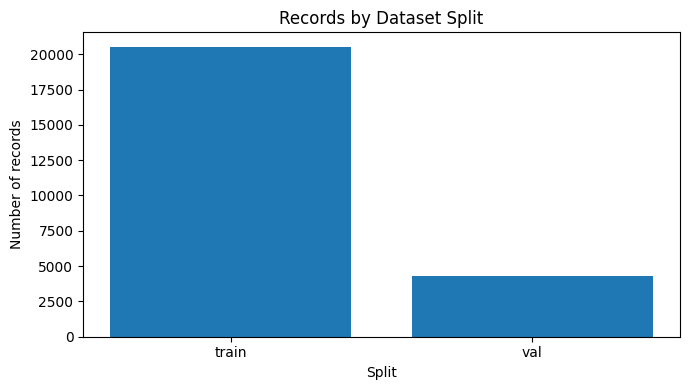

In [ ]:
# Figure 1: split sizes
split_counts = df["split"].value_counts()
plt.figure(figsize=(7, 4))
plt.bar(split_counts.index, split_counts.values)
plt.title("Records by Dataset Split")
plt.xlabel("Split")
plt.ylabel("Number of records")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01_records_by_split.png", dpi=200)
plt.show()

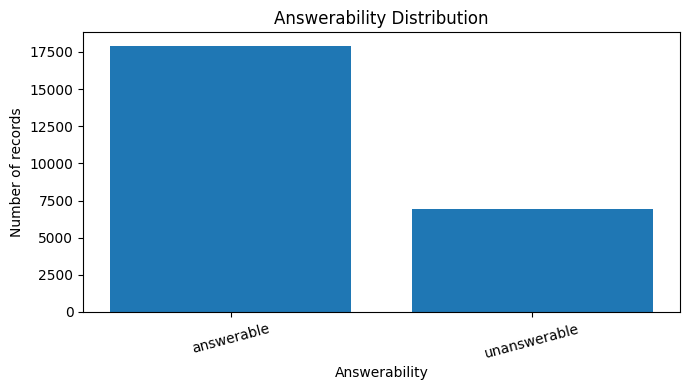

In [ ]:
# Figure 2: answerability distribution
answerability_counts = df["answerable_label"].value_counts(dropna=False)
plt.figure(figsize=(7, 4))
plt.bar(answerability_counts.index, answerability_counts.values)
plt.title("Answerability Distribution")
plt.xlabel("Answerability")
plt.ylabel("Number of records")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "02_answerability_distribution.png", dpi=200)
plt.show()

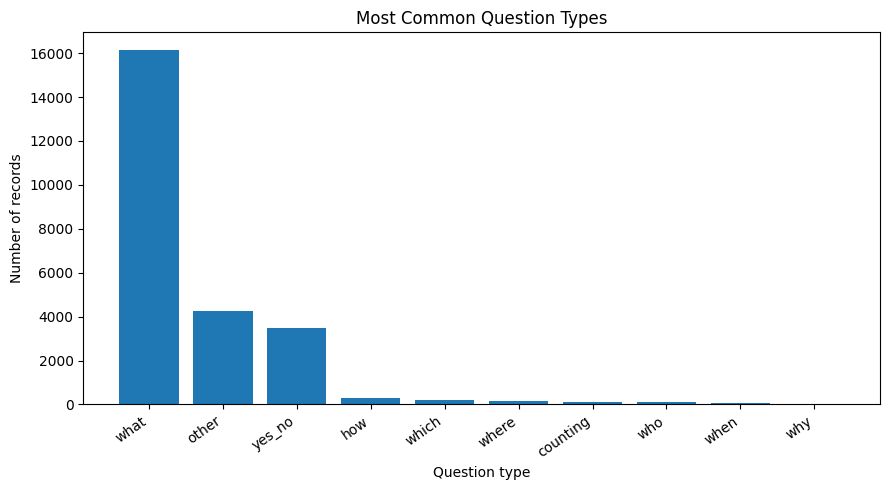

In [ ]:
# Figure 3: question types
qtype_counts = df["question_type"].value_counts().head(12)
plt.figure(figsize=(9, 5))
plt.bar(qtype_counts.index, qtype_counts.values)
plt.title("Most Common Question Types")
plt.xlabel("Question type")
plt.ylabel("Number of records")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03_question_types.png", dpi=200)
plt.show()

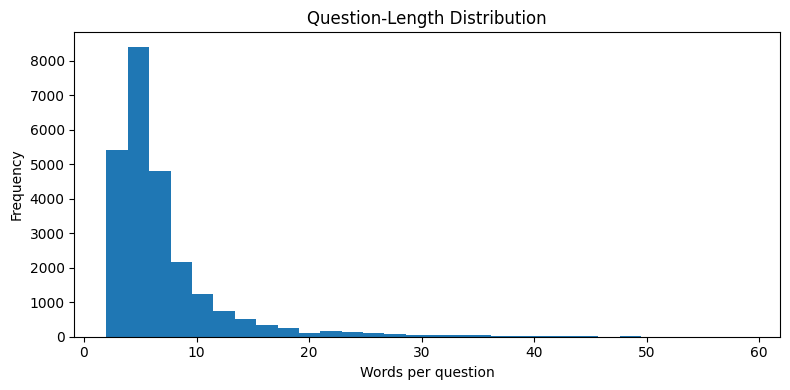

,question_word_count
count,24842.000000
mean,6.757829
std,5.425679
min,2.000000
25%,4.000000
50%,5.000000
75%,7.000000
max,59.000000


In [ ]:
# Figure 4: question word count
plt.figure(figsize=(8, 4))
plt.hist(df["question_word_count"], bins=30)
plt.title("Question-Length Distribution")
plt.xlabel("Words per question")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04_question_length.png", dpi=200)
plt.show()

display(df["question_word_count"].describe().to_frame("question_word_count"))

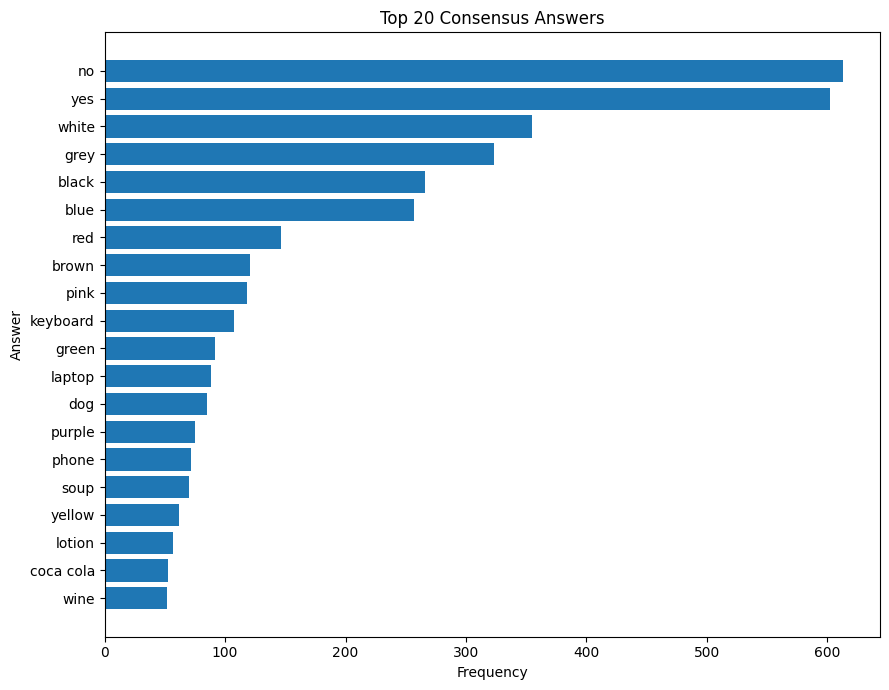

In [ ]:
# Figure 5: top consensus answers (excluding unanswerable)
top_answers = (
    df.loc[df["consensus_answer"].ne("unanswerable"), "consensus_answer"]
    .replace("", np.nan)
    .dropna()
    .value_counts()
    .head(20)
    .sort_values()
)
plt.figure(figsize=(9, 7))
plt.barh(top_answers.index, top_answers.values)
plt.title("Top 20 Consensus Answers")
plt.xlabel("Frequency")
plt.ylabel("Answer")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05_top_answers.png", dpi=200)
plt.show()

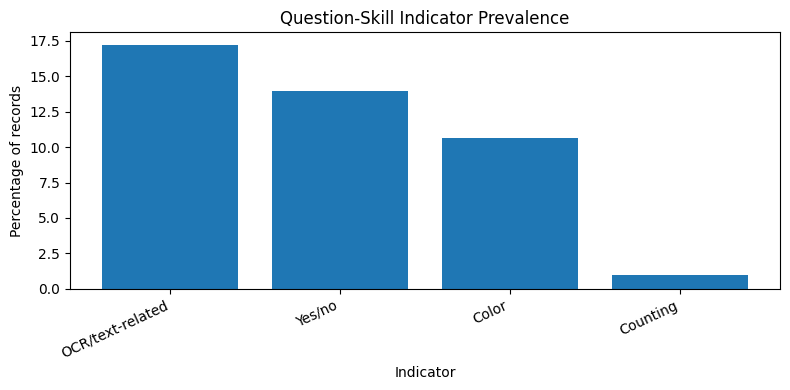

,percent
OCR/text-related,17.24
Yes/no,13.96
Color,10.67
Counting,0.98


In [ ]:
# Figure 6: visual-skill indicator prevalence
skill_rates = pd.Series({
    "OCR/text-related": df["is_ocr_related"].mean(),
    "Counting": df["is_counting_question"].mean(),
    "Color": df["is_color_question"].mean(),
    "Yes/no": df["is_yes_no_question"].mean(),
}).sort_values(ascending=False) * 100

plt.figure(figsize=(8, 4))
plt.bar(skill_rates.index, skill_rates.values)
plt.title("Question-Skill Indicator Prevalence")
plt.xlabel("Indicator")
plt.ylabel("Percentage of records")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "06_skill_indicators.png", dpi=200)
plt.show()

display(skill_rates.round(2).to_frame("percent"))

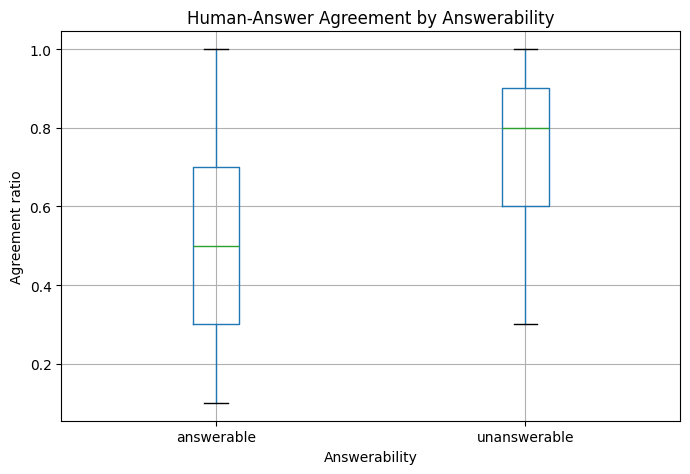

In [ ]:
# Figure 7: answer disagreement by answerability
agreement_plot = df.dropna(subset=["answer_agreement"]).boxplot(
    column="answer_agreement",
    by="answerable_label",
    figsize=(7, 5)
)
plt.title("Human-Answer Agreement by Answerability")
plt.suptitle("")
plt.xlabel("Answerability")
plt.ylabel("Agreement ratio")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "07_answer_agreement.png", dpi=200)
plt.show()

In [ ]:
# Figure 8: image brightness and sharpness, when available
quality_plot_df = df.dropna(subset=["brightness_mean", "sharpness_proxy"])

if len(quality_plot_df) > 0:
    plt.figure(figsize=(7, 5))
    plt.scatter(
        quality_plot_df["brightness_mean"],
        quality_plot_df["sharpness_proxy"],
        alpha=0.25,
        s=12
    )
    plt.title("Brightness vs. Sharpness Proxy")
    plt.xlabel("Mean grayscale brightness")
    plt.ylabel("Sharpness proxy")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "08_brightness_vs_sharpness.png", dpi=200)
    plt.show()
else:
    print("Image features are unavailable; Figure 8 was skipped.")

Image features are unavailable; Figure 8 was skipped.


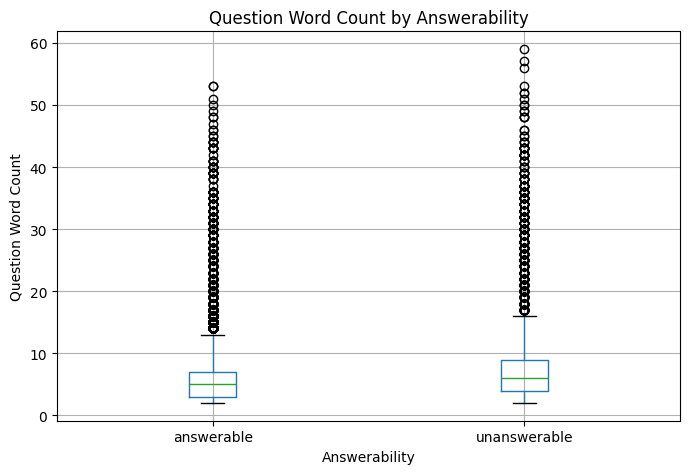

In [ ]:
boxplot_word_count = df.boxplot(
    column="question_word_count",
    by="answerable_label",
    figsize=(7, 5)
)
plt.title("Question Word Count by Answerability")
plt.suptitle("")
plt.xlabel("Answerability")
plt.ylabel("Question Word Count")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "question_word_count_by_answerability.png", dpi=200)
plt.show()

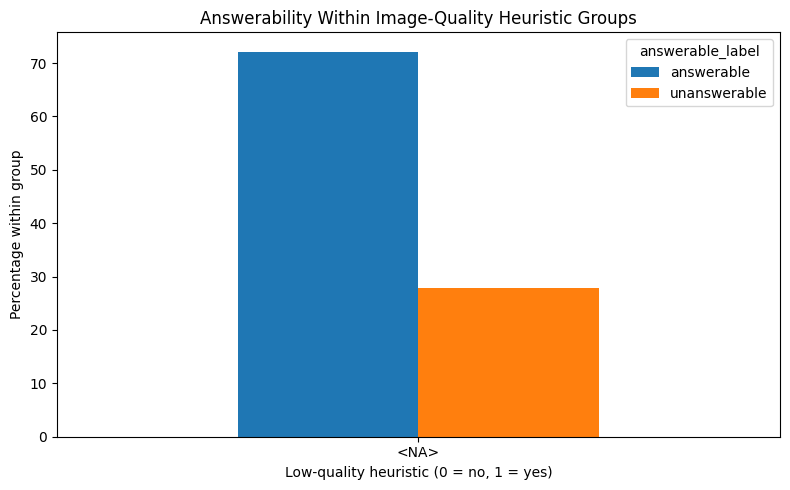

answerable_label,answerable,unanswerable
low_quality_heuristic,,
<NA>,72.16,27.84


In [ ]:
# Figure 9: answerability by low-quality heuristic
quality_answerability = pd.crosstab(
    df["low_quality_heuristic"],
    df["answerable_label"],
    normalize="index",
    dropna=False
) * 100

if not quality_answerability.empty:
    quality_answerability.plot(kind="bar", figsize=(8, 5))
    plt.title("Answerability Within Image-Quality Heuristic Groups")
    plt.xlabel("Low-quality heuristic (0 = no, 1 = yes)")
    plt.ylabel("Percentage within group")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "09_quality_vs_answerability.png", dpi=200)
    plt.show()
    display(quality_answerability.round(2))
else:
    print("Quality grouping is unavailable; Figure 9 was skipped.")

    print("Displaying empty crosstab result for context:")
    display(pd.crosstab(
        df["low_quality_heuristic"],
        df["answerable_label"],
        normalize="index",
        dropna=False
    ).round(2))

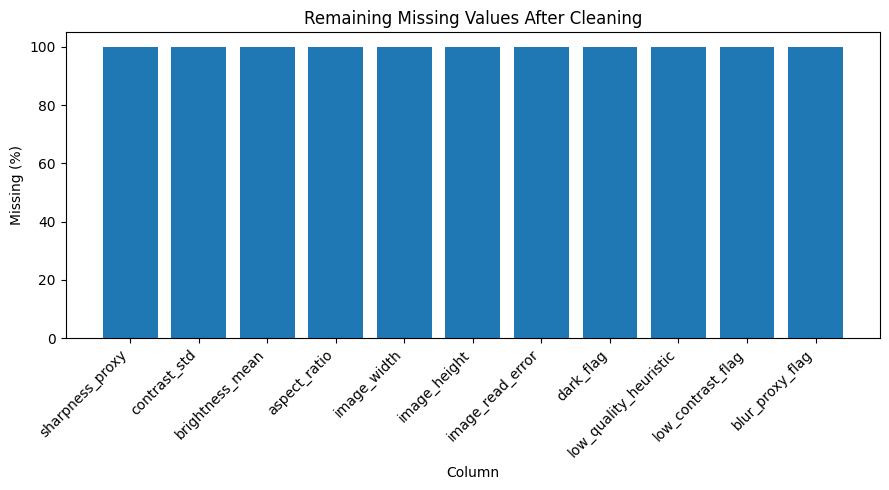

In [ ]:
# Figure 10: missingness after cleaning
missing_after = (df.isna().mean() * 100).sort_values(ascending=False)
missing_after = missing_after[missing_after > 0].head(20)

if len(missing_after):
    plt.figure(figsize=(9, 5))
    plt.bar(missing_after.index, missing_after.values)
    plt.title("Remaining Missing Values After Cleaning")
    plt.xlabel("Column")
    plt.ylabel("Missing (%)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "10_remaining_missingness.png", dpi=200)
    plt.show()
else:
    print("No remaining missing values.")

## 13. Qualitative record inspection



In [ ]:
inspection_columns = [
    "split", "image", "question", "consensus_answer", "answerable_label",
    "question_type", "is_ocr_related", "low_quality_heuristic",
    "answer_agreement", "answer_entropy"
]

print("Sample answerable records")
display(df[df["answerable"] == 1][inspection_columns].sample(
    min(5, (df["answerable"] == 1).sum()), random_state=RANDOM_STATE
))

print("Sample unanswerable records")
display(df[df["answerable"] == 0][inspection_columns].sample(
    min(5, (df["answerable"] == 0).sum()), random_state=RANDOM_STATE
))

print("Sample OCR-related records")
display(df[df["is_ocr_related"] == 1][inspection_columns].sample(
    min(5, (df["is_ocr_related"] == 1).sum()), random_state=RANDOM_STATE
))

Sample answerable records


,split,image,question,consensus_answer,answerable_label,question_type,is_ocr_related,low_quality_heuristic,answer_agreement,answer_entropy
3118,train,VizWiz_train_00003118.jpg,can you please describe this card and its orientation thank you,hierophant sideways,answerable,yes_no,0,<NA>,0.2,2.921928
23121,val,VizWiz_val_00002598.jpg,what is in this box,playing cards,answerable,what,0,<NA>,0.6,1.295462
6761,train,VizWiz_train_00006761.jpg,what is this bottle,candy cane,answerable,what,0,<NA>,0.2,2.721928
18418,train,VizWiz_train_00018418.jpg,what color is this,blue,answerable,what,0,<NA>,0.9,0.468996
22573,val,VizWiz_val_00002050.jpg,what color is the cabinets,white,answerable,what,0,<NA>,0.9,0.468996


Sample unanswerable records


,split,image,question,consensus_answer,answerable_label,question_type,is_ocr_related,low_quality_heuristic,answer_agreement,answer_entropy
1978,train,VizWiz_train_00001978.jpg,ok this is the last side if we don't find it here i think i'm going to eat something else we want convectional oven ...,unanswerable,unanswerable,other,1,<NA>,0.9,0.468996
19478,train,VizWiz_train_00019478.jpg,what is the book that i have just taken a picture of it's my wife's birthday and i need to know which one it is so i...,unanswerable,unanswerable,what,0,<NA>,0.8,0.921928
17737,train,VizWiz_train_00017737.jpg,how muchwhat bill is this,unanswerable,unanswerable,how,0,<NA>,1.0,-0.000000
10518,train,VizWiz_train_00010518.jpg,what is this,unanswerable,unanswerable,what,0,<NA>,0.6,1.770951
20969,val,VizWiz_val_00000446.jpg,what is this paper for,unanswerable,unanswerable,what,0,<NA>,1.0,-0.000000


Sample OCR-related records


,split,image,question,consensus_answer,answerable_label,question_type,is_ocr_related,low_quality_heuristic,answer_agreement,answer_entropy
24510,val,VizWiz_val_00003987.jpg,what does this box say on top,mary kay,answerable,what,1,<NA>,0.8,0.721928
3806,train,VizWiz_train_00003806.jpg,what does this page say,unanswerable,unanswerable,what,1,<NA>,0.8,0.921928
17456,train,VizWiz_train_00017456.jpg,what does this say,unanswerable,unanswerable,what,1,<NA>,0.7,1.356780
14938,train,VizWiz_train_00014938.jpg,what does this say,unanswerable,answerable,what,1,<NA>,0.3,2.170951
21359,val,VizWiz_val_00000836.jpg,what does this card say,unanswerable,unanswerable,what,1,<NA>,0.7,1.356780


In [ ]:

def show_examples(frame, title, n=4):
    sample = frame[frame["image_file_exists"]].head(n)
    if sample.empty:
        print(f"No image files available for: {title}")
        return
    plt.figure(figsize=(14, 4))
    for i, (_, row) in enumerate(sample.iterrows(), start=1):
        plt.subplot(1, len(sample), i)
        try:
            with Image.open(row["image_path"]) as im:
                plt.imshow(im.convert("RGB"))
            plt.title(
                f"{row['question'][:45]}\nAns: {row['consensus_answer'][:25]}",
                fontsize=8
            )
            plt.axis("off")
        except Exception:
            plt.axis("off")
            plt.title("Image read error")
    plt.suptitle(title)
    plt.tight_layout()
    safe = re.sub(r"[^a-z0-9]+", "_", title.lower()).strip("_")
    plt.savefig(FIGURE_DIR / f"sample_{safe}.png", dpi=200)
    plt.show()

show_examples(df[df["answerable"] == 1], "Sample Answerable Images")
show_examples(df[df["answerable"] == 0], "Sample Unanswerable Images")
show_examples(df[df["low_quality_heuristic"] == 1], "Sample Heuristic Low-Quality Images")

No image files available for: Sample Answerable Images
No image files available for: Sample Unanswerable Images
No image files available for: Sample Heuristic Low-Quality Images


## 14. Encoding and optional scaling


In [ ]:
categorical_features = ["question_type", "question_first_word"]
numeric_features = [
    "question_word_count", "question_char_count", "answer_word_count",
    "num_human_answers", "answer_agreement", "answer_entropy",
    "brightness_mean", "contrast_std", "sharpness_proxy"
]
binary_features = [
    "is_ocr_related", "is_counting_question", "is_color_question",
    "is_yes_no_question", "dark_flag", "low_contrast_flag",
    "blur_proxy_flag", "low_quality_heuristic"
]

available_numeric = [c for c in numeric_features if c in df.columns]
available_binary = [c for c in binary_features if c in df.columns]

train_mask = df["split"].eq("train")
X_train = df.loc[train_mask, categorical_features + available_numeric + available_binary].copy()
X_all = df[categorical_features + available_numeric + available_binary].copy()

# Fill numerical missing values with training medians.
train_medians = X_train[available_numeric].median(numeric_only=True)
X_train[available_numeric] = X_train[available_numeric].fillna(train_medians)
X_all[available_numeric] = X_all[available_numeric].fillna(train_medians)

# Fill missing binary values with 0 only for the optional tabular representation.
X_train[available_binary] = X_train[available_binary].fillna(0)
X_all[available_binary] = X_all[available_binary].fillna(0)

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", ohe, categorical_features),
        ("numeric", StandardScaler(), available_numeric),
        ("binary", "passthrough", available_binary),
    ],
    remainder="drop"
)

preprocessor.fit(X_train)
encoded_array = preprocessor.transform(X_all)
encoded_feature_names = preprocessor.get_feature_names_out()
encoded_df = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=df.index)

print("Encoded feature matrix shape:", encoded_df.shape)
display(encoded_df.head())

joblib.dump(preprocessor, OUTPUT_DIR / "phase3_tabular_preprocessor.joblib")
print("Saved fitted preprocessor.")

Encoded feature matrix shape: (24842, 365)


,categorical__question_type_counting,categorical__question_type_how,categorical__question_type_other,categorical__question_type_what,categorical__question_type_when,categorical__question_type_where,categorical__question_type_which,categorical__question_type_who,categorical__question_type_why,categorical__question_type_yes_no,categorical__question_first_word_-of,categorical__question_first_word_17,categorical__question_first_word_3,categorical__question_first_word_a,categorical__question_first_word_about,categorical__question_first_word_above,categorical__question_first_word_actually,categorical__question_first_word_again,categorical__question_first_word_all,categorical__question_first_word_alright,categorical__question_first_word_alrighty,categorical__question_first_word_am,categorical__question_first_word_and,categorical__question_first_word_answer,categorical__question_first_word_any,categorical__question_first_word_anything,categorical__question_first_word_are,categorical__question_first_word_around,categorical__question_first_word_as,categorical__question_first_word_ask,categorical__question_first_word_at,categorical__question_first_word_audio,categorical__question_first_word_awesome,categorical__question_first_word_baby,categorical__question_first_word_baking,categorical__question_first_word_based,categorical__question_first_word_basically,categorical__question_first_word_being,categorical__question_first_word_book,categorical__question_first_word_brahma,categorical__question_first_word_brand,categorical__question_first_word_brandon,categorical__question_first_word_bus,categorical__question_first_word_by,categorical__question_first_word_caffeinated,categorical__question_first_word_calorie,categorical__question_first_word_cam,categorical__question_first_word_camp,categorical__question_first_word_can,categorical__question_first_word_can't,...,categorical__question_first_word_we,categorical__question_first_word_we'll,categorical__question_first_word_we're,categorical__question_first_word_well,categorical__question_first_word_were,categorical__question_first_word_whar,categorical__question_first_word_what,categorical__question_first_word_what's,categorical__question_first_word_whatpage,categorical__question_first_word_whats,categorical__question_first_word_whatwhat,categorical__question_first_word_when,categorical__question_first_word_where,categorical__question_first_word_where's,categorical__question_first_word_which,categorical__question_first_word_who,categorical__question_first_word_who's,categorical__question_first_word_whole,categorical__question_first_word_whoops,categorical__question_first_word_whose,categorical__question_first_word_why,categorical__question_first_word_will,categorical__question_first_word_wine,categorical__question_first_word_with,categorical__question_first_word_wonder,categorical__question_first_word_wondering,categorical__question_first_word_working,categorical__question_first_word_would,categorical__question_first_word_y,categorical__question_first_word_yeah,categorical__question_first_word_yes,categorical__question_first_word_you,categorical__question_first_word_your,numeric__question_word_count,numeric__question_char_count,numeric__answer_word_count,numeric__num_human_answers,numeric__answer_agreement,numeric__answer_entropy,numeric__brightness_mean,numeric__contrast_std,numeric__sharpness_proxy,binary__is_ocr_related,binary__is_counting_question,binary__is_color_question,binary__is_yes_no_question,binary__dark_flag,binary__low_contrast_flag,binary__blur_proxy_flag,binary__low_quality_heuristic
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.125908,-0.000641,0.656505,0.009872,0.540815,-0.858566,NaN,NaN,NaN

Saved fitted preprocessor.


## 15. Define the Phase 4 evaluation subset



In [ ]:
subset_source = df[df["split"] == "val"].copy()
if len(subset_source) < SUBSET_SIZE:
    print("Validation split is smaller than the requested subset; using all available validation rows.")
    eval_subset = subset_source.copy()
else:
    subset_source["stratum"] = (
        subset_source["answerable_label"].astype(str) + "|" +
        subset_source["low_quality_heuristic"].fillna(-1).astype(str) + "|" +
        subset_source["is_ocr_related"].astype(str)
    )

    groups = subset_source.groupby("stratum", group_keys=False)
    group_sizes = groups.size()
    allocations = (group_sizes / group_sizes.sum() * SUBSET_SIZE).round().astype(int)
    allocations = allocations.clip(lower=1)

    sampled_parts = []
    for stratum, group in groups:
        n = min(int(allocations.get(stratum, 1)), len(group))
        sampled_parts.append(group.sample(n=n, random_state=RANDOM_STATE))

    eval_subset = pd.concat(sampled_parts)
    # The 'answers_list' column contains lists, which are unhashable.
    # Droping this column before calling drop_duplicates which uses hashing internally.
    # 'answers_list' is not essential for identifying unique records for the subset.
    if "answers_list" in eval_subset.columns:
        eval_subset = eval_subset.drop(columns=["answers_list"])
    eval_subset = eval_subset.drop_duplicates()

    # Adjusting to exact target when possible.
    if len(eval_subset) > SUBSET_SIZE:
        eval_subset = eval_subset.sample(SUBSET_SIZE, random_state=RANDOM_STATE)
    elif len(eval_subset) < SUBSET_SIZE:
        remaining = subset_source.drop(index=eval_subset.index)
        extra_n = min(SUBSET_SIZE - len(eval_subset), len(remaining))
        if extra_n > 0:
            eval_subset = pd.concat([
                eval_subset,
                remaining.sample(extra_n, random_state=RANDOM_STATE)
            ])

eval_subset = eval_subset.sort_values(["answerable_label", "question_type", "image"]).reset_index(drop=True)

print("Evaluation subset size:", len(eval_subset))
display(pd.crosstab(
    eval_subset["answerable_label"],
    eval_subset["low_quality_heuristic"],
    margins=True
))

Evaluation subset size: 1000


low_quality_heuristic
answerable_label


## 16. Export processed datasets and documentation

In [ ]:
export_df = df.copy()
export_df["answers_json"] = export_df["answers_list"].map(
    lambda x: json.dumps(x, ensure_ascii=False)
)
export_df = export_df.drop(columns=["answers_list", "question_raw"], errors="ignore")

subset_export = eval_subset.copy()

subset_export = subset_export.drop(columns=["answers_list", "question_raw"], errors="ignore")

export_df.to_csv(OUTPUT_DIR / "vizwiz_processed_phase3.csv", index=False)
subset_export.to_csv(OUTPUT_DIR / "vizwiz_defined_evaluation_subset.csv", index=False)
encoded_df.to_csv(OUTPUT_DIR / "vizwiz_encoded_tabular_features.csv", index=False)

data_dictionary = pd.DataFrame([
    ("split", "Dataset partition: train or val."),
    ("image", "Image filename or identifier from the annotation."),
    ("image_path", "Located local image path; empty when unavailable."),
    ("question", "Normalized natural-language question."),
    ("consensus_answer", "Most frequent normalized human answer."),
    ("answerable", "1=answerable, 0=unanswerable, missing=not reported."),
    ("answer_agreement", "Fraction of human answers matching the modal answer."),
    ("answer_entropy", "Entropy of the human-answer distribution; higher means more disagreement."),
    ("question_type", "Rule-based category derived from the question opening."),
    ("is_ocr_related", "Rule-based flag for text-reading intent."),
    ("is_counting_question", "Rule-based counting-intent flag."),
    ("is_color_question", "Rule-based color-intent flag."),
    ("image_width", "Image width in pixels."),
    ("image_height", "Image height in pixels."),
    ("brightness_mean", "Mean grayscale pixel intensity."),
    ("contrast_std", "Standard deviation of grayscale intensity."),
    ("sharpness_proxy", "Variance of edge-filter response; relative sharpness proxy."),
    ("dark_flag", "1 when brightness is in the lowest dataset decile."),
    ("low_contrast_flag", "1 when contrast is in the lowest dataset decile."),
    ("blur_proxy_flag", "1 when sharpness proxy is in the lowest dataset decile."),
    ("low_quality_heuristic", "1 when any transparent image-quality heuristic is triggered."),
], columns=["column", "description"])

data_dictionary.to_csv(OUTPUT_DIR / "phase3_data_dictionary.csv", index=False)

summary = {
    "rows_raw": int(len(raw_df)),
    "rows_processed": int(len(df)),
    "train_rows_processed": int((df["split"] == "train").sum()),
    "val_rows_processed": int((df["split"] == "val").sum()),
    "answerable_rows": int((df["answerable"] == 1).sum()),
    "unanswerable_rows": int((df["answerable"] == 0).sum()),
    "image_files_found": int(df["image_file_exists"].sum()),
    "evaluation_subset_rows": int(len(eval_subset)),
    "quality_thresholds": quality_thresholds,
    "random_state": RANDOM_STATE,
}
with open(OUTPUT_DIR / "phase3_processing_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Exported files:")
for p in sorted(OUTPUT_DIR.iterdir()):
    print(" -", p.name)


Exported files:
 - phase3_data_dictionary.csv
 - phase3_processing_summary.json
 - phase3_tabular_preprocessor.joblib
 - vizwiz_defined_evaluation_subset.csv
 - vizwiz_encoded_tabular_features.csv
 - vizwiz_processed_phase3.csv


## Feature Derivation Summary

| Feature              | Description                                |
| -------------------- | ------------------------------------------ |
| question_word_count  | Number of words in the question            |
| question_char_count  | Number of characters                       |
| question_type        | what/where/how/yes-no/etc.                 |
| is_ocr_related       | Whether the question requires reading text |
| is_color_question    | Color-related question                     |
| is_counting_question | Counting question                          |
| answer_agreement     | Agreement among annotators                 |
| answer_entropy       | Diversity of answers                       |
